
=== Porównanie wyników eksperymentów ===
                   exp_name  fid_mean  fid_std  is_mean_mean  is_mean_std  precision_mean  precision_std  recall_mean  recall_std  params.lr  params.d_to_g_ratio  params.nz
               dcgan_ratio2     79.48     3.48          2.88         0.07            0.61           0.06         0.02        0.01        0.0                  2.0      128.0
               dcgan_ratio3     81.45     3.06          3.01         0.12            0.55           0.05         0.01        0.00        0.0                  3.0      128.0
                 dcgan_nz32     91.24     6.54          3.15         0.16            0.54           0.06         0.02        0.01        0.0                  1.0       32.0
               dcgan_ratio5     94.45     6.82          3.14         0.08            0.59           0.04         0.01        0.00        0.0                  5.0      128.0
              dcgan_default     99.04     9.67          3.22         0.15            0.61    

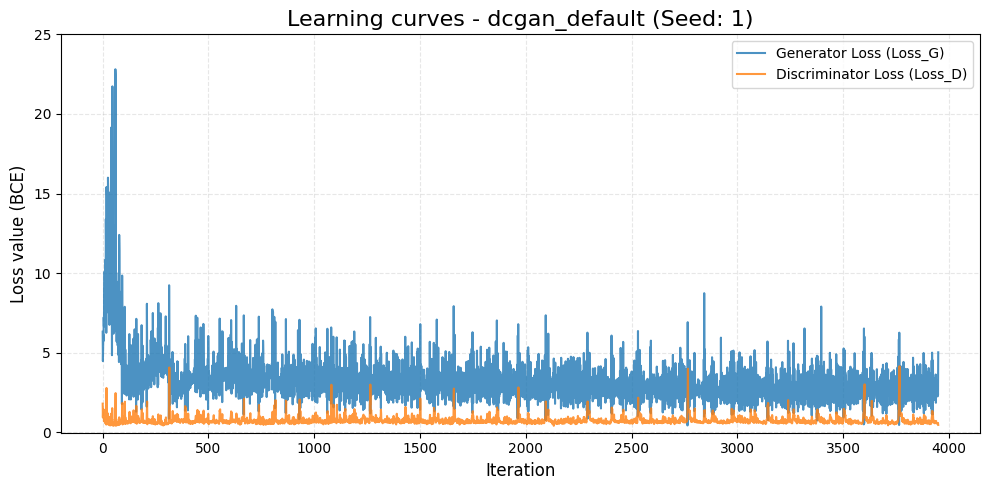

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_gan_losses(metrics_path: str | Path, save_dir: str | Path = None):

    metrics_path = Path(metrics_path)
    if not metrics_path.exists():
        print(f"Nie znaleziono pliku: {metrics_path}")
        return

    with open(metrics_path, "r") as f:
        data = json.load(f)

    losses_G = data.get("loss_G", [])
    losses_D = data.get("loss_D", [])

    if not losses_G or not losses_D:
        print("Plik JSON nie zawiera list loss_G lub loss_D.")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label="Generator Loss (Loss_G)", alpha=0.8)
    plt.plot(losses_D, label="Discriminator Loss (Loss_D)", alpha=0.8)

    plt.title(
        f"Learning curves - {data.get('exp_name', 'Experiment')} (Seed: {data.get('seed', 'N/A')})",  fontsize=16
    )
    plt.ylim((-0.02, 25))
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Loss value (BCE)",  fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if save_dir:
        save_path = (
            Path(save_dir)
            / f"{data.get('exp_name', 'experiment')}_seed{data.get('seed', '0')}_losses.pdf"
        )
        plt.savefig(save_path, dpi=300)
        print(f"Zapisano wykres do: {save_path}")
    else:
        plt.show()


def compare_summaries(results_dir: str | Path):

    results_dir = Path(results_dir)
    summary_files = list(results_dir.glob("summary_*.json"))

    if not summary_files:
        print(f"Brak plików summary_*.json w folderze {results_dir}")
        return pd.DataFrame()

    all_data = []
    for filepath in summary_files:
        with open(filepath, "r") as f:
            data = json.load(f)
            if isinstance(data, list):
                all_data.extend(data)
            else:
                all_data.append(data)

    if not all_data:
        return pd.DataFrame()

    df = pd.json_normalize(all_data)

    if "fid_mean" in df.columns:
        df = df.sort_values(by="fid_mean", ascending=True)

    print("\n=== Porównanie wyników eksperymentów ===")

    cols_to_show = [
        "exp_name",
        "fid_mean",
        "fid_std",
        "is_mean_mean",
        "is_mean_std",
        "precision_mean",
        "precision_std",
        "recall_mean",
        "recall_std",
        "params.lr",
        "params.d_to_g_ratio",
        "params.nz",
    ]
    existing_cols = [c for c in cols_to_show if c in df.columns]

    print(df[existing_cols].round(2).to_string(index=False))

    return df


if __name__ == "__main__":

    results_folder = "results"
    df_metrics = compare_summaries(results_folder)

    if not df_metrics.empty:
        df_metrics.to_csv(
            Path(results_folder) / "all_experiments_comparison.csv", index=False
        )
        print(
            f"\nZapisano pełną tabelę do pliku: {results_folder}/all_experiments_comparison.csv"
        )


    specific_metrics_file = "results/dcgan_default/seed1/metrics.json"

    if Path(specific_metrics_file).exists():
        plot_gan_losses(specific_metrics_file, "plots")

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_gan_losses_mean_std(exp_dir: str | Path, save_dir: str | Path = None):
    """
    Szuka plików metrics.json ze wszystkich seedów w podanym katalogu eksperymentu,
    oblicza średnią i odchylenie standardowe dla loss_G i loss_D, a następnie rysuje wykres.
    """
    exp_dir = Path(exp_dir)
    if not exp_dir.exists():
        print(f"Nie znaleziono katalogu: {exp_dir}")
        return

    metric_files = list(exp_dir.glob("**/metrics.json"))
    
    if not metric_files:
        print(f"Nie znaleziono żadnych plików metrics.json w katalogu {exp_dir}.")
        return

    all_losses_G = []
    all_losses_D = []
    exp_name = "Experiment"

    for file in metric_files:
        with open(file, "r") as f:
            data = json.load(f)
            
        if "exp_name" in data and exp_name == "Experiment":
            exp_name = data["exp_name"]

        loss_g = data.get("loss_G", [])
        loss_d = data.get("loss_D", [])

        if loss_g and loss_d:
            all_losses_G.append(loss_g)
            all_losses_D.append(loss_d)

    if not all_losses_G:
        print("Pliki JSON nie zawierają list loss_G lub loss_D.")
        return

    min_len = min(len(g) for g in all_losses_G)
    all_losses_G = np.array([g[:min_len] for g in all_losses_G])
    all_losses_D = np.array([d[:min_len] for d in all_losses_D])

    mean_G = np.mean(all_losses_G, axis=0)
    std_G = np.std(all_losses_G, axis=0)
    
    mean_D = np.mean(all_losses_D, axis=0)
    std_D = np.std(all_losses_D, axis=0)

    iterations = np.arange(min_len)

    plt.figure(figsize=(10, 5))
    
    plt.plot(iterations, mean_G, label="Generator Loss (Mean)", color="C0")
    plt.fill_between(iterations, mean_G - std_G, mean_G + std_G, color="C0", alpha=0.2)

    plt.plot(iterations, mean_D, label="Discriminator Loss (Mean)", color="C1")
    plt.fill_between(iterations, mean_D - std_D, mean_D + std_D, color="C1", alpha=0.2)

    plt.title(
        f"Learning curves (Mean ± Std) - {exp_name} ({len(metric_files)} seeds)", fontsize=16
    )
    plt.xlabel("Iteration", fontsize=12)
    plt.ylim((0, 15))
    plt.ylabel("Loss value (BCE)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if save_dir:
        save_path = Path(save_dir) / f"{exp_name}_losses_mean_std.pdf"
        plt.savefig(save_path, dpi=300)
        print(f"Zapisano wykres do: {save_path}")
    else:
        plt.show()

Zapisano wykres do: plots/dcgan_default_losses_mean_std.pdf


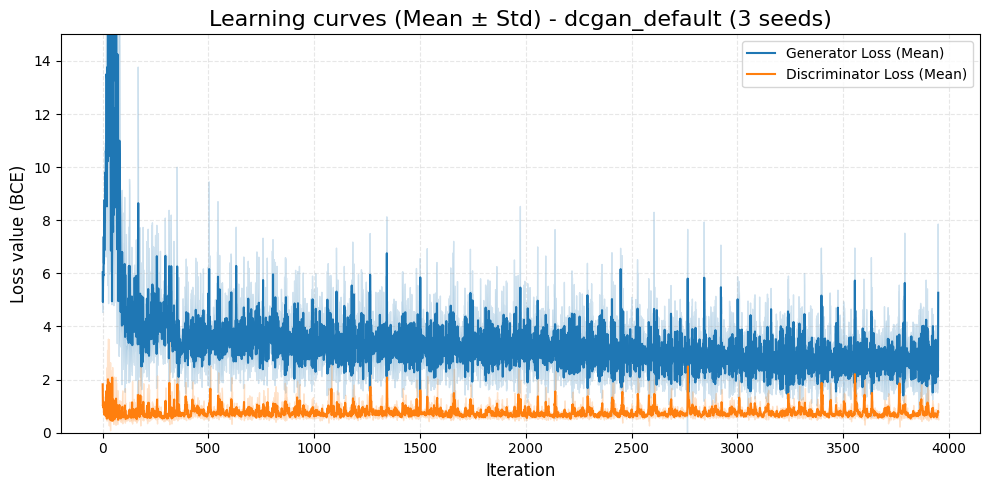

In [5]:
plot_gan_losses_mean_std("results/dcgan_default/", "plots")

Zapisano wykres do: plots/dcgan_ratio2_losses_mean_std.pdf


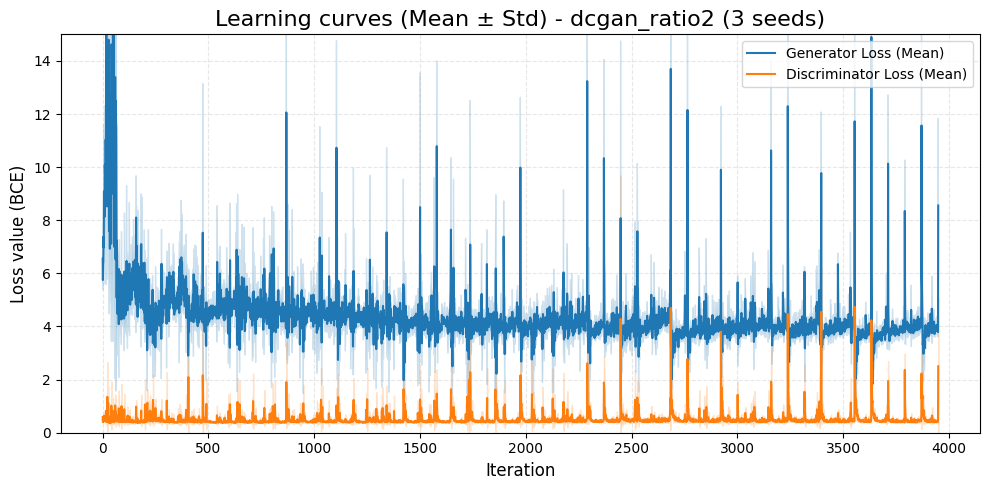

In [6]:
plot_gan_losses_mean_std("results/dcgan_ratio2/", "plots")

Zapisano wykres do: plots/dcgan_g_to_d_ratio5_losses_mean_std.pdf


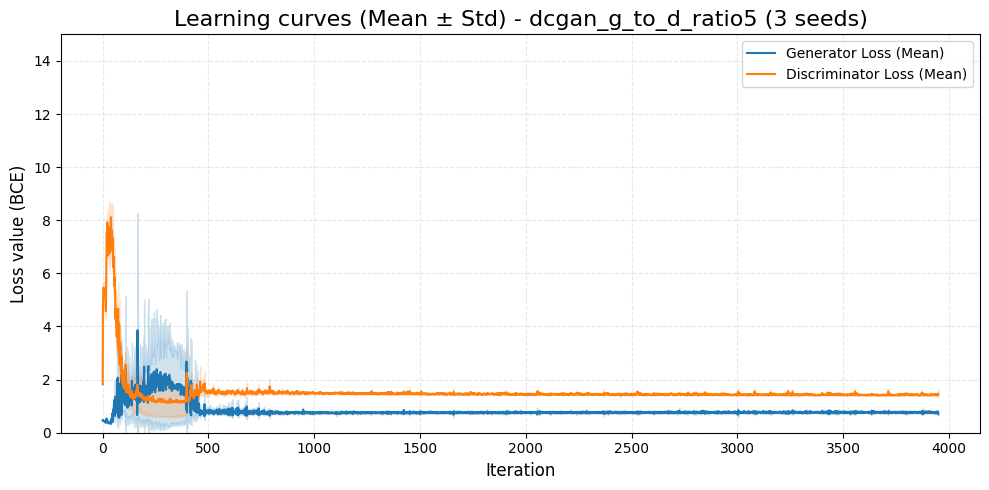

In [7]:
plot_gan_losses_mean_std("results/dcgan_g_to_d_ratio5/", "plots")

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_ddim_losses_mean_std(exp_dir: str | Path, save_dir: str | Path = None, loss_key: str = "loss", loss_name: str = "MSE"):

    exp_dir = Path(exp_dir)
    if not exp_dir.exists():
        print(f"Nie znaleziono katalogu: {exp_dir}")
        return

    metric_files = list(exp_dir.glob("**/metrics.json"))
    
    if not metric_files:
        print(f"Nie znaleziono żadnych plików metrics.json w katalogu {exp_dir}.")
        return

    all_losses = []
    exp_name = "Experiment"

    for file in metric_files:
        with open(file, "r") as f:
            data = json.load(f)
            
        if "exp_name" in data and exp_name == "Experiment":
            exp_name = data["exp_name"]

        loss = data.get(loss_key, [])

        if loss:
            all_losses.append(loss)

    if not all_losses:
        print(f"Pliki JSON nie zawierają listy pod kluczem '{loss_key}'.")
        return

    min_len = min(len(l) for l in all_losses)
    all_losses = np.array([l[:min_len] for l in all_losses])

    mean_loss = np.mean(all_losses, axis=0)
    std_loss = np.std(all_losses, axis=0)

    iterations = np.arange(min_len)

    plt.figure(figsize=(10, 5))
    
    plt.plot(iterations, mean_loss, label="Training Loss (Mean)", color="C0")
    plt.fill_between(iterations, mean_loss - std_loss, mean_loss + std_loss, color="C0", alpha=0.2)

    plt.title(
        f"Learning curve (Mean ± Std) - {exp_name} ({len(metric_files)} seeds)", fontsize=16
    )
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Loss value (MSE)" if loss_name == "MSE" else "Loss value", fontsize=12) 
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if save_dir:
        save_path = Path(save_dir) / f"{exp_name}_losses_mean_std.pdf"
        plt.savefig(save_path, dpi=300)
        print(f"Zapisano wykres do: {save_path}")
    else:
        plt.show()

Zapisano wykres do: plots/ddim_default_losses_mean_std.pdf


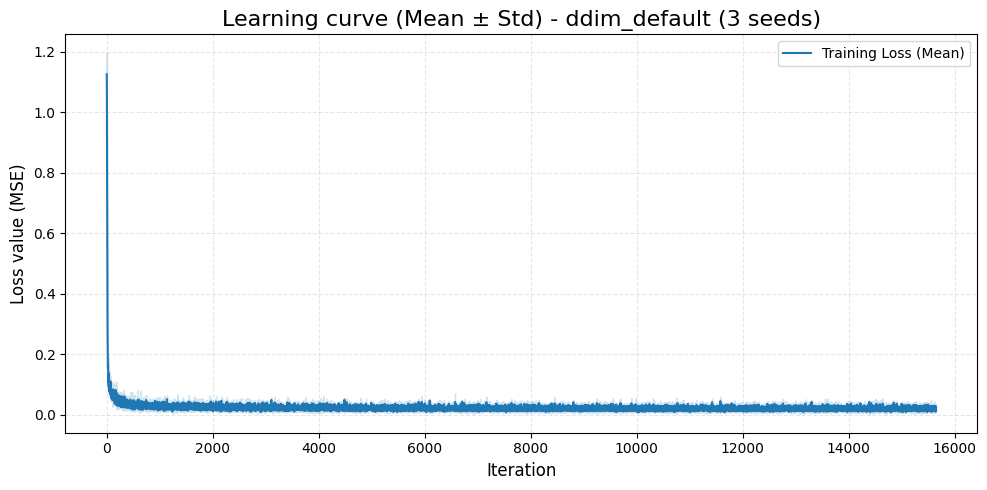

In [9]:
plot_ddim_losses_mean_std("results/ddim_default/", "plots")

Zapisano wykres do: plots/vae_default_losses_mean_std.pdf


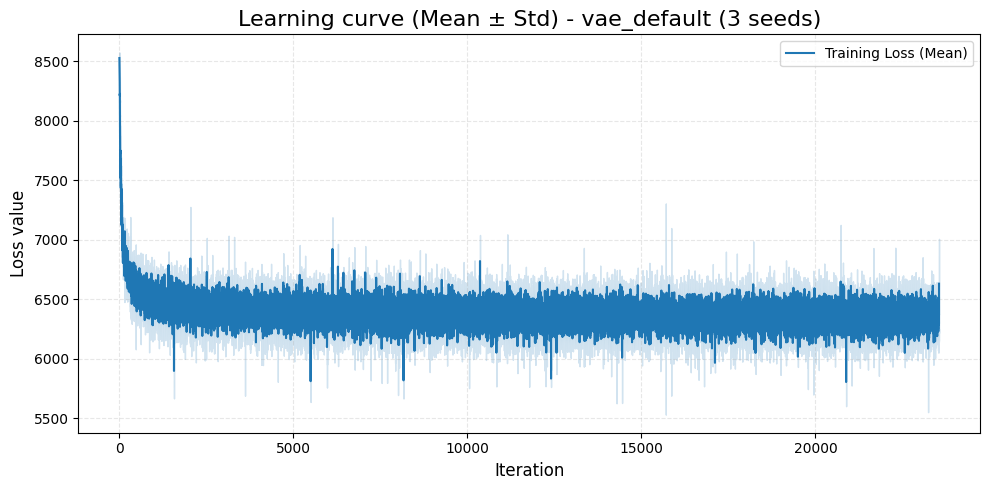

In [12]:
plot_ddim_losses_mean_std("results/vae_default/", "plots", loss_name="loss")